In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, log_loss, recall_score
import joblib

df3 = pd.read_csv('df_limpio_1y2.csv')

# Separar variables inputs y variable output
y = df3["made_sla"]
x = df3.drop("made_sla", axis=1)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Construcción y entrenamiento del modelo (MLPClassifier)
model_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='logistic',
    solver='adam',
    max_iter=200,
    early_stopping=True,
    random_state=42
)

model_mlp.fit(X_train, y_train)

y_pred = model_mlp.predict(X_test)

# Qué porcentaje de predicciones totales fueron correctas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Log-loss (función de pérdida):", log_loss(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

objeto_guardado = {
    "modelo": model_mlp,
    "columnas": list(x.columns)
}

# Guardar todo en un archivo .pkl
joblib.dump(objeto_guardado, "modelo_mlp_con_columnas.pkl")



Accuracy: 0.9744554734910853
Precision: 0.9872503723901134
Log-loss (función de pérdida): 0.9207180594764367
Recall: 0.9853597076981228


Este modelo, se encarga de predecir una variable de respuesta binaria (made_sla). El modelo utiliza el optimizador Adam para guiar el aprendizaje de la red neuronal, ajustando sus parámetros de manera eficiente para reducir el error en cada paso del entrenamiento, buscando cada vez un óptimo. Aunque se le especifica la función de activación logistic (el nombre de sigmoid en esta librería) para las capas ocultas, la importancia de sigmoid es en la capa de salida. En este caso, la función sigmoide es ideal, ya que su salida es una probabilidad entre 0 y 1. Esto permite que el modelo clasifique cada caso como "sí" o "no", y que la función de pérdida (log-loss) pueda medir su rendimiento de manera precisa.


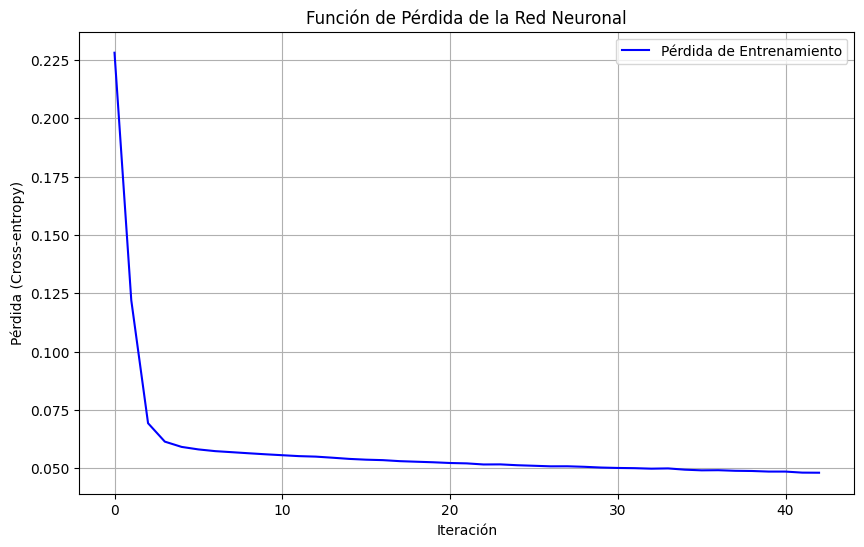

In [ ]:
import matplotlib.pyplot as plt
loss_values = model_mlp.loss_curve_

plt.figure(figsize=(10, 6))
plt.plot(loss_values, 'b', label='Pérdida de Entrenamiento')
plt.title('Función de Pérdida de la Red Neuronal')
plt.xlabel('Iteración')
plt.ylabel('Pérdida (Cross-entropy)')
plt.legend()
plt.grid(True)
plt.show()

Este código crea un gráfico para que se pueda ver cómo el error de la red neuronal cambia con el tiempo. Primero, extrae la lista de errores que tu modelo guardó durante el entrenamiento. Después, usa esa información para dibujar una línea en un gráfico. El gráfico muestra las iteraciones (cada paso de entrenamiento) en el eje horizontal y el error del modelo en el eje vertical.